# spatial multi-omics alignment with paired images

Tutorial 3: spatial multi-omics alignment with paired images (image-to-image)

## 1. Load package and data paths

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import cv2
try:
    START_DIR = Path(__file__).resolve().parent
except NameError:
    START_DIR = Path.cwd()

PROJECT_ROOT = next(
    candidate for candidate in (START_DIR, *START_DIR.parents)
    if (candidate / "SPOmiAlign").is_dir()
)
spomialign_path = PROJECT_ROOT / "SPOmiAlign"
if str(spomialign_path) not in sys.path:
    sys.path.insert(0, str(spomialign_path))

from tutorial_utils import get_tutorial_paths, run_image_to_image_alignment, read_bgr

DATA_DIR, OUTPUT_ROOT = get_tutorial_paths(PROJECT_ROOT)
target_image_path= "Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/E15_5-S1-HE.jpg"
source_image_path= "Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/E15_5-S2-HE_warped_rt15.png"
target_h5ad_path="Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/s1_rna_mapped.h5ad"
source_h5ad_path="Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/s2_motif_unaligned.h5ad"
%matplotlib inline

[OK] Successfully imported 'rasterize_h5ad_to_image' from data_process.py
Data directory: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/Data
Output directory: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output


## 2. Parameter settings

| Parameter | Meaning |
| --- | --- |
| `SAMPLE_ID` | Output folder name under `output/img_2_img/`. |
| `target_image_path` | Fixed reference image path in data. |
| `source_image_path` | Moving image path in data. |
| `target_h5ad_path` | Target spatial omics file already mapped to the reference image frame. |
| `source_h5ad_path` | Source spatial omics file to transform with the image alignment. |
| `target_h5ad_spatial_key` / `source_h5ad_spatial_key` | Coordinate key used by the corresponding h5ad file. |
| `Alignment_mode` | SPOmiAlign supports three alignment modes: Rigid (`Rigid`), Affine (`Affine`, `Homography`), and Non-Rigid (`bspline`, `affine+bspline`). |
| `device` | Torch device used by alignment, for example `cuda:0`, `cuda:1`, or `cpu`; `None` keeps automatic selection. |



In [2]:
PARAMS = {
    "sample_id": "S2toS1",
    "target_image_path": target_image_path,
    "source_image_path": source_image_path,
    "target_h5ad_path": target_h5ad_path,
    "source_h5ad_path": source_h5ad_path,
    "target_h5ad_spatial_key": "spatial",
    "source_h5ad_spatial_key": "spatial",
    "Alignment_mode": "affine+bspline",
    "device": "cuda:1",
}
PARAMS


{'sample_id': 'S2toS1',
 'target_image_path': 'Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/E15_5-S1-HE.jpg',
 'source_image_path': 'Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/E15_5-S2-HE_warped_rt15.png',
 'target_h5ad_path': 'Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/s1_rna_mapped.h5ad',
 'source_h5ad_path': 'Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/s2_motif_unaligned.h5ad',
 'target_h5ad_spatial_key': 'spatial',
 'source_h5ad_spatial_key': 'spatial',
 'Alignment_mode': 'affine+bspline',
 'device': 'cuda:1'}

## 3. Run SPOmiAlign

Target image: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/Data/Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/E15_5-S1-HE.jpg
Source image: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/Data/Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/E15_5-S2-HE_warped_rt15.png
Target h5ad: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/Data/Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/s1_rna_mapped.h5ad
Source h5ad: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/Data/Tutorial 3 spatial multi-omics alignment with paired images(image-to-image)/s2_motif_unaligned.h5ad
Using device: cuda:1


2026-05-15 09:04:27.889 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (201, 206, 209)
Processing H5AD coordinates...
[OK] Step 00 source coordinates mapped to render space: 1939/1939 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/img_2_img/S2toS1/alignment/debug_step_00_source_in_render_space.png
Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 02 after resize to registration grid (source resized canvas): 1939/1939 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/img_2_img/S2toS1/alignment/debug_step_02_after_resize_to_registration.png
Columns not found or not specified. Updating adata.obsm['spatial']
[OK] Step 03 after registration transform (target resized canvas): 1786/1939 points inside canvas -> /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/img_2_img/S2toS1/alignment/debug_step_03_after_registration_transform.png
[OK] Step 04 af

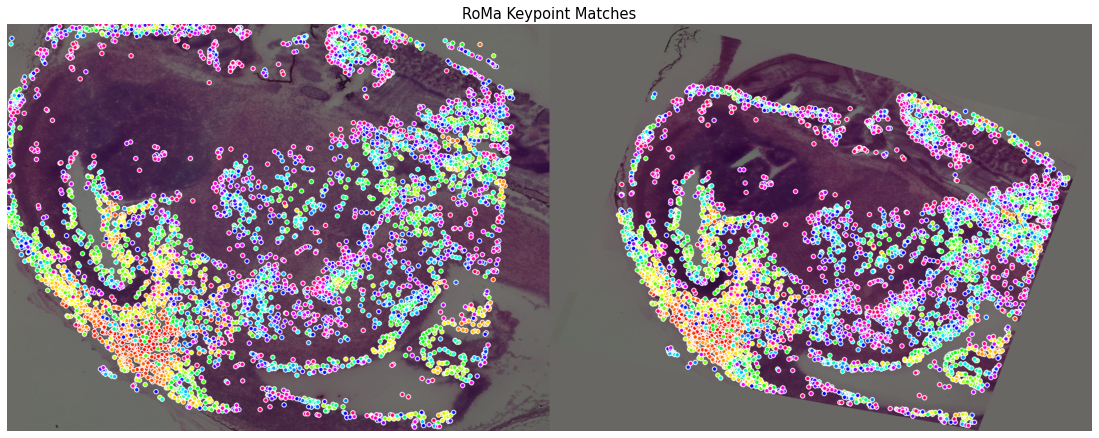

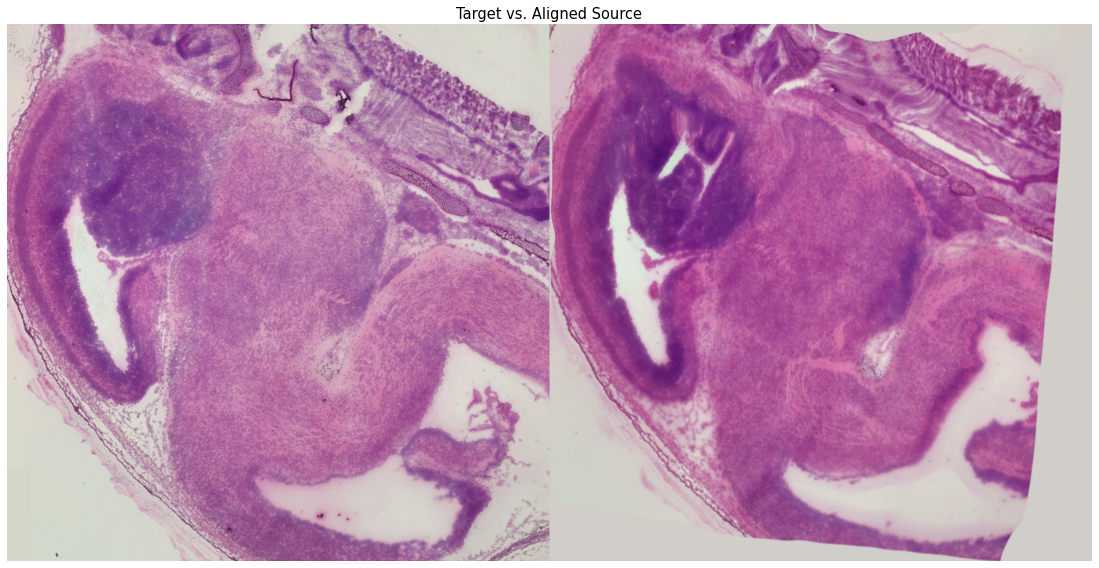

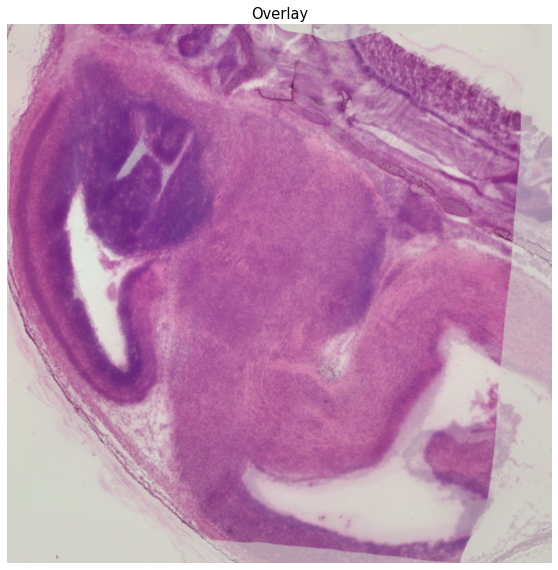

Alignment runtime: 7.9475 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/img_2_img/S2toS1/alignment
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/img_2_img/S2toS1/alignment/target_h5ad_scatter.png (1911x1890, background=black, shape=square, points=1949)
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/img_2_img/S2toS1/alignment/transformed_h5ad_scatter.png (1911x1890, background=black, shape=square, points=1939)


In [3]:
result = run_image_to_image_alignment(
    data_root=DATA_DIR,
    output_root=OUTPUT_ROOT,
    **PARAMS,
)

## 4. Outputs

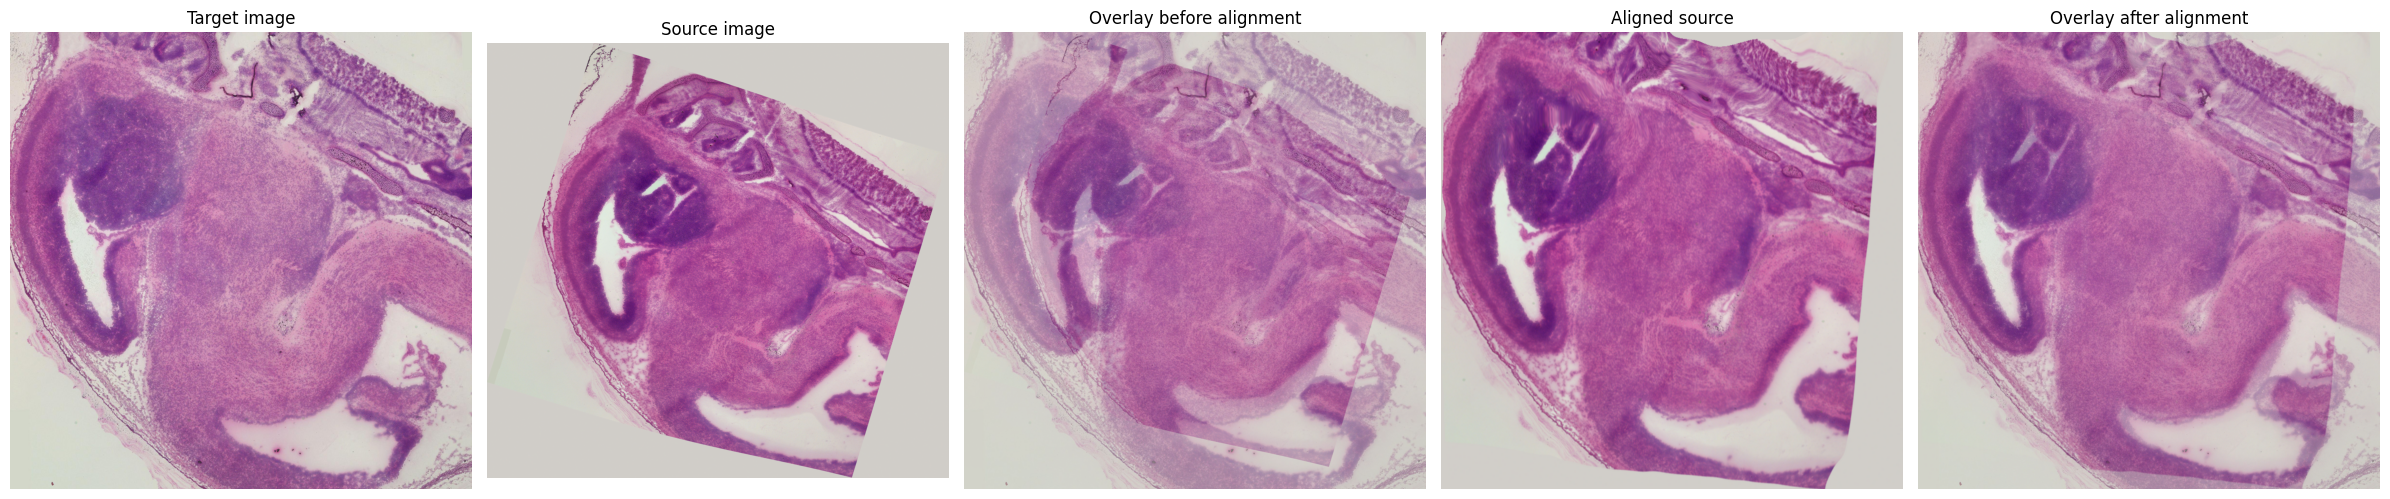

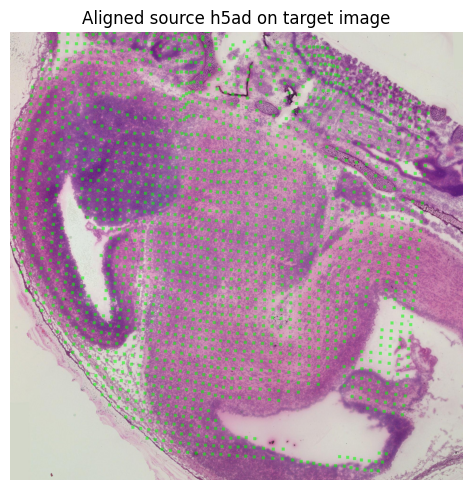

Save transformed h5ad path to  /storage/hermes/yiwang/spomialign/Final/SPOmiAlign-main/output/img_2_img/S2toS1/alignment/transformed.h5ad


In [4]:
images=[result["target_section_visualization"], result["source_section_visualization"], result["before_overlay"], result["aligned_source"], result["after_overlay"]]
titles=["Target image", "Source image", "Overlay before alignment", "Aligned source", "Overlay after alignment"]
figsize=(24, 5)
titles = titles or ["" for _ in images]
if figsize is None:
    figsize = (5.5 * len(images), 5.5)
fig, axes = plt.subplots(1, len(images), figsize=figsize)
if len(images) == 1:
    axes = [axes]
for ax, image_or_path, title in zip(axes, images, titles):
    image = read_bgr(image_or_path) if isinstance(image_or_path, (str, Path)) else image_or_path
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

images=[
    result["h5ad_overlay"],
]
titles=[ "Aligned source h5ad on target image"]
figsize=(15, 5)
titles = titles or ["" for _ in images]
if figsize is None:
    figsize = (5.5 * len(images), 5.5)
fig, axes = plt.subplots(1, len(images), figsize=figsize)
if len(images) == 1:
    axes = [axes]
for ax, image_or_path, title in zip(axes, images, titles):
    image = read_bgr(image_or_path) if isinstance(image_or_path, (str, Path)) else image_or_path
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Save transformed h5ad path to ", result["transformed_h5ad"])
